# Challenges in Representation Learning: Facial Expression Recognition Challenge

https://www.kaggle.com/c/challenges-in-representation-learning-facial-expression-recognition-challenge

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import keras
from keras.preprocessing import image

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.mixed_precision import experimental as mixed_precision

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("API de precisão mista experimental encontrada. Habilitando...")
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_policy(policy)
    
    print("Política de precisão experimental definida com sucesso.")
else:
    print("Nenhuma GPU encontrada. A precisão mista não será habilitada.")

API de precisão mista experimental encontrada. Habilitando...
Política de precisão experimental definida com sucesso.


In [4]:
from keras import applications as keras_applications

In [5]:
!pip install keras_applications
!pip install git+https://github.com/rcmalli/keras-vggface.git

     |████████████████████████████████| 50 kB 4.2 MB/s  eta 0:00:01
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.
  Cloning https://github.com/rcmalli/keras-vggface.git to /tmp/pip-req-build-m1hfeeef
  Created wheel for keras-vggface: filename=keras_vggface-0.6-py3-none-any.whl size=8301 sha256=8437df50cf86d3a3f0610dda9f2ef79841d5e560fdad95305789f6d2e991d955
  Stored in directory: /tmp/pip-ephem-wheel-cache-ko2pv83f/wheels/08/df/86/0225d44647ab2256dbf1e006823288fe9cc86367a056e6ea2c
Successfully built keras-vggface
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [6]:
from keras_vggface.vggface import VGGFace
from keras_vggface import utils

# Data Preprocess

In [ ]:
import pandas as pd
import numpy as np

print("--- Iniciando Carregamento dos Dados ---")

path_fer2013_orig = '/kaggle/input/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv'
path_fer2013_plus = '/kaggle/input/ferplus/fer2013new.csv'

try:
    data_orig = pd.read_csv(path_fer2013_orig)
    data_plus = pd.read_csv(path_fer2013_plus)
    print("Arquivos CSV carregados com sucesso.")
except FileNotFoundError as e:
    print(f"ERRO FATAL: Arquivo não encontrado. Verifique os caminhos.")
    print(e)
    raise

data_orig.columns = data_orig.columns.str.strip()

print(f"Colunas em icml_face_data.csv (original): {list(data_orig.columns)}")
print(f"Colunas em fer2013new.csv (plus): {list(data_plus.columns)}")

if 'pixels' not in data_orig.columns:
    print("ERRO FATAL: A coluna 'pixels' NÃO foi encontrada em icml_face_data.csv.")
    print("Por favor, verifique o arquivo.")
    raise AttributeError("Coluna 'pixels' não encontrada no CSV original.")
else:
    print("Coluna 'pixels' encontrada com sucesso.")
    
if 'Usage' not in data_plus.columns:
    print("ERRO FATAL: A coluna 'Usage' NÃO foi encontrada em fer2013new.csv.")
    raise AttributeError("Coluna 'Usage' não encontrada no CSV do FER-Plus.")
else:
    print("Coluna 'Usage' encontrada com sucesso no FER-Plus.")


data = pd.concat([data_orig['pixels'], data_plus], axis=1)
print("DataFrames concatenados.")

emotion_cols = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
other_cols = ['unknown', 'NF']

all_labels = emotion_cols + other_cols
data['majority_label_str'] = data[all_labels].idxmax(axis=1)

data = data[~data['majority_label_str'].isin(other_cols)]
print(f"Total de imagens após filtrar 'NF' e 'unknown': {len(data)}")

emotion_mapping = {label: idx for idx, label in enumerate(emotion_cols)}
data['emotion'] = data['majority_label_str'].map(emotion_mapping)
print("Rótulos do FER-Plus processados (voto majoritário).")

train_data = data[data.Usage=='Training']
val_data = data[data.Usage=='PublicTest']
test_data = data[data.Usage=='PrivateTest']
print("Dados divididos em Treino, Validação e Teste.")

print("\n--- DIAGNÓSTICO FINAL ---")
print(f"Colunas em 'train_data' (final): {list(train_data.columns)}")

if 'pixels' not in train_data.columns:
    print("ERRO: 'pixels' NÃO está em 'train_data' após a divisão.")
else:
    print("SUCESSO: 'pixels' está presente em 'train_data'.")
    
if 'emotion' not in train_data.columns:
    print("ERRO: 'emotion' NÃO está em 'train_data' após a divisão.")
else:
    print("SUCESSO: 'emotion' está presente em 'train_data'.")

print("--------------------------")

--- Iniciando Carregamento dos Dados ---
Arquivos CSV carregados com sucesso.
Colunas em icml_face_data.csv (original): ['emotion', 'Usage', 'pixels']
Colunas em fer2013new.csv (plus): ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']
Coluna 'pixels' encontrada com sucesso.
Coluna 'Usage' encontrada com sucesso no FER-Plus.
DataFrames concatenados.
Total de imagens após filtrar 'NF' e 'unknown': 35488
Rótulos do FER-Plus processados (voto majoritário).
Dados divididos em Treino, Validação e Teste.

--- DIAGNÓSTICO FINAL ---
Colunas em 'train_data' (final): ['pixels', 'Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF', 'majority_label_str', 'emotion']
SUCESSO: 'pixels' está presente em 'train_data'.
SUCESSO: 'emotion' está presente em 'train_data'.
--------------------------


In [8]:
data.Usage.unique()

array(['Training', 'PublicTest', 'PrivateTest'], dtype=object)

In [9]:
train_data.shape, val_data.shape, test_data.shape

((28389, 15), (3553, 15), (3546, 15))

In [ ]:
import collections
import imblearn
# oversampler = imblearn.over_sampling.RandomOverSampler()

In [11]:
collections.Counter(train_data.emotion)

Counter({0: 10309, 3: 3515, 1: 7528, 2: 3562, 4: 2467, 6: 652, 7: 165, 5: 191})

In [12]:
from keras.utils import to_categorical

# x_train, y_train = oversampler.fit_resample(train_data.pixels.values.reshape(-1,1),train_data.emotion.values)

# # x_train = train_data.pixels.values.reshape(-1,1)
# # y_train = train_data.emotion.values

# x_val = val_data.pixels.values.reshape(-1,1)
# y_val = val_data.emotion.values

# x_test = test_data.pixels.values.reshape(-1,1)
# y_test = test_data.emotion.values

In [ ]:
from sklearn.utils import class_weight
import numpy as np
import collections


print("--- Usando dados de treino originais (sem oversampling) ---")
x_train = train_data.pixels.values.reshape(-1, 1)
y_train = train_data.emotion.values

x_val = val_data.pixels.values.reshape(-1, 1)
y_val = val_data.emotion.values

x_test = test_data.pixels.values.reshape(-1, 1)
y_test = test_data.emotion.values

print("Distribuição original das classes de treino:", collections.Counter(y_train))


print("\n--- Calculando pesos de classe para balanceamento ---")
class_weights_raw = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train                 
)

class_weights_smooth = np.sqrt(class_weights_raw)

class_weight_dict = {i: float(weight) for i, weight in enumerate(class_weights_smooth)}

print("Pesos de classe calculados (versão 'balanced' original):")
print({i: float(w) for i, w in enumerate(class_weights_raw)})

print("\nPesos de classe SUAVIZADOS que serão usados no treinamento:")
print(class_weight_dict)

--- Usando dados de treino originais (sem oversampling) ---
Distribuição original das classes de treino: Counter({0: 10309, 1: 7528, 2: 3562, 3: 3515, 4: 2467, 6: 652, 5: 191, 7: 165})

--- Calculando pesos de classe para balanceamento ---
Pesos de classe calculados (versão 'balanced' original):
{0: 0.3442259190998157, 1: 0.47139014346439956, 2: 0.9962450870297586, 3: 1.009566145092461, 4: 1.4384373733279288, 5: 18.57918848167539, 6: 5.442676380368098, 7: 21.506818181818183}

Pesos de classe SUAVIZADOS que serão usados no treinamento:
{0: 0.5867076947678594, 1: 0.6865785777785377, 2: 0.9981207777767972, 3: 1.0047716880428414, 4: 1.1993487288224092, 5: 4.310358277646464, 6: 2.3329544316955912, 7: 4.6375444129213665}


In [14]:
collections.Counter(y_train)

Counter({0: 10309, 3: 3515, 1: 7528, 2: 3562, 4: 2467, 6: 652, 7: 165, 5: 191})

In [15]:
x_train = list(x_train)
x_val   = list(x_val)
x_test  = list(x_test)

for i,item in enumerate(x_train):
    x_train[i] = np.fromstring(item[0], sep=' ').reshape(48,48,1).astype(np.uint8)
for i,item in enumerate(x_val):
    x_val[i] = np.fromstring(item[0], sep=' ').reshape(48,48,1).astype(np.uint8)
for i,item in enumerate(x_test):
    x_test[i] = np.fromstring(item[0], sep=' ').reshape(48,48,1).astype(np.uint8)
    
x_train = np.vstack(x_train).reshape(-1,48,48,1).astype(np.uint8)
x_val = np.vstack(x_val).reshape(-1,48,48,1).astype(np.uint8)
x_test = np.vstack(x_test).reshape(-1,48,48,1).astype(np.uint8)

In [16]:
y_train = to_categorical(y_train,num_classes=8)
y_val   = to_categorical(y_val  ,num_classes=8)
y_test  = to_categorical(y_test ,num_classes=8)

In [17]:
from copy import deepcopy as copy

def smooth_labels(y, smooth_factor):
    '''Convert a matrix of one-hot row-vector labels into smoothed versions.

    # Arguments
        y: matrix of one-hot row-vector labels to be smoothed
        smooth_factor: label smoothing factor (between 0 and 1)

    # Returns
        A matrix of smoothed labels.
    '''
    assert len(y.shape) == 2, 'input should be a batch of one-hot-encoded data'
    y2 = copy(y)
    if 0 <= smooth_factor <= 1:
        # label smoothing ref: https://www.robots.ox.ac.uk/~vgg/rg/papers/reinception.pdf
        y2 *= 1 - smooth_factor
        y2 += smooth_factor / y.shape[1]
    else:
        raise Exception(
            'Invalid label smoothing factor: ' + str(smooth_factor))
    return y2

In [ ]:
!pip install albumentations
from keras.utils import Sequence
from keras.utils import to_categorical
import cv2
from math import floor
import albumentations as A
import numpy as np

def preprocess_input_vggface_manual(x):
    """
    Pré-processamento correto para VGGFace2 (ResNet50).
    Espera entrada RGB 0-255.
    Converte para BGR e subtrai as médias, SEM dividir por 127.5.
    """
    x_temp = x.copy().astype('float32')
    x_temp = x_temp[..., ::-1]
    x_temp[..., 0] -= 91.4953
    x_temp[..., 1] -= 103.8827
    x_temp[..., 2] -= 131.0912
    return x_temp

class data_sequence(Sequence):
    def __init__(self, features, labels, batch_size=128, target_dim=(224,224), 
                 n_classes=8, shuffle=True, augment=False):
        'Initialization'
        assert len(features)==len(labels), 'number of feature and labels not consistent'
        self.features = features
        self.labels = labels
        self.batch_size = batch_size
        self.target_dim = target_dim
        self.target_channels = 3
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augment = augment
        self.sample_count = len(labels)
        self.indexes = np.arange(self.sample_count)

        if self.augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.Rotate(limit=15, p=0.7),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
                A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
            ])

    def __len__(self):
        'Denotes the number of batches per epoch'
        return floor(self.sample_count / self.batch_size)

    def __gray2RGB__(self,x):
      if len(x.shape)==2:
        return np.stack((x,x,x),-1)
      else:
        assert len(x.shape)==3
        if len(x[0,0,:]) == 1:
          return np.stack((x[:,:,0],x[:,:,0],x[:,:,0]),-1)
        else:
          assert len(x[0,0,:])==self.target_channels
      return x


    def __getitem__(self, idx):
        'Generate one batch of data'
        indexes = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        X = np.empty((self.batch_size, *self.target_dim, self.target_channels))
        Y = np.empty((self.batch_size, self.n_classes))
        for i,ind in enumerate(indexes):
            x = self.features[ind]
            if self.augment:
                transformed = self.transform(image=x)
                x = transformed['image']
            
            x = cv2.resize(x, self.target_dim, interpolation=cv2.INTER_CUBIC)
            x = self.__gray2RGB__(x)
            
            X[i] = preprocess_input_vggface_manual(x)

            
            y = self.labels[ind]
            Y[i] = y
        return np.array(X), np.array(Y)

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [19]:
train_sequence = data_sequence(x_train,y_train,batch_size=16,target_dim=(224,224),n_classes=8,shuffle=False)
feature,lable = train_sequence.__getitem__(0)

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

def cbam_block(cbam_feature, ratio=8):
    """Versão do CBAM que substitui as camadas Lambda por operações TensorFlow diretas."""
    
    channel_axis = -1
    channel = cbam_feature.shape[channel_axis]
    shared_layer_one = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    avg_pool_channel = GlobalAveragePooling2D()(cbam_feature)    
    avg_pool_channel = Reshape((1, 1, channel))(avg_pool_channel)
    avg_pool_channel = shared_layer_one(avg_pool_channel)
    avg_pool_channel = shared_layer_two(avg_pool_channel)
    max_pool_channel = GlobalMaxPooling2D()(cbam_feature)
    max_pool_channel = Reshape((1, 1, channel))(max_pool_channel)
    max_pool_channel = shared_layer_one(max_pool_channel)
    max_pool_channel = shared_layer_two(max_pool_channel)
    cbam_channel = Add()([avg_pool_channel, max_pool_channel])
    cbam_channel = Activation('sigmoid')(cbam_channel)
    channel_refined_feature = multiply([cbam_feature, cbam_channel])
    
    avg_pool_spatial = tf.reduce_mean(channel_refined_feature, axis=3, keepdims=True)
    max_pool_spatial = tf.reduce_max(channel_refined_feature, axis=3, keepdims=True)
    
    concat = Concatenate(axis=3)([avg_pool_spatial, max_pool_spatial])
    
    cbam_spatial = Conv2D(filters=1, kernel_size=(7, 7), strides=1, padding='same', activation='sigmoid', 
                          kernel_initializer='he_normal', use_bias=False, name='spatial_attention_map')(concat)
                        
    cbam_feature_refined = multiply([channel_refined_feature, cbam_spatial])
    
    return cbam_feature_refined

print("Função do bloco CBAM definida.")

Função do bloco CBAM definida.


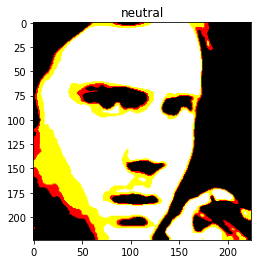

In [21]:
emotion_dict = {
    0: 'neutral',
    1: 'happiness',
    2: 'surprise',
    3: 'sadness',
    4: 'anger',
    5: 'disgust',
    6: 'fear',
    7: 'contempt'
}

import matplotlib.pyplot as plt
plt.imshow(feature[0,:,:,:])
plt.title(emotion_dict[np.argmax(lable[0])]);

# Model

In [22]:
vggface = VGGFace(model='resnet50', include_top=False, input_shape = (224,224,3))
vggface.trainable = False
vggface.summary()

94699520/94694792 [==============================] - 3s 0us/step
Model: "vggface_resnet50"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1/7x7_s2 (Conv2D)           (None, 112, 112, 64) 9408        input_1[0][0]                    
__________________________________________________________________________________________________
conv1/7x7_s2/bn (BatchNormaliza (None, 112, 112, 64) 256         conv1/7x7_s2[0][0]               
__________________________________________________________________________________________________
activation (Activation)         (None, 112, 112, 64) 0           conv1/7x7_s2/bn[0][0]            
__________________

In [23]:
from keras.models import Sequential
from keras.layers import Input
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization

# model = Sequential([vggface,
#                     Flatten(),
#                     Dropout(0.5),
#                     BatchNormalization(),
#                     Dense(128, activation='relu'),
#                     Dropout(0.5),
#                     BatchNormalization(),
#                     Dense(len(emotion_dict), activation='softmax', name = 'classifer')])
# model = Sequential([vggface,
#                     Flatten(),
#                     Dropout(0.25),
#                     Dense(2048, activation='relu'),
#                     Dropout(0.25),
#                     Dense(1024, activation='relu'),
#                     Dense(8, name = 'classifer')])
# model.summary()

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout


vggface_base = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3), pooling=None)
vggface_base.trainable = False

last_layer = vggface_base.output

if len(last_layer.shape) == 4 and last_layer.shape[1] == 1:
    print("AVISO: Base com Pooling detectada. Conectando na camada anterior...")
    last_layer = vggface_base.layers[-2].output

print(f"Formato de entrada para o CBAM: {last_layer.shape}")

attention_output = cbam_block(last_layer)

x = Flatten()(attention_output)
x = Dropout(0.25)(x)
x = Dense(2048, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(1024, activation='relu')(x)
outputs = Dense(8, name='classifer')(x)

model_cbam = Model(inputs=vggface_base.input, outputs=outputs)
model_cbam.summary()
model = model_cbam

AVISO: Base com Pooling detectada. Conectando na camada anterior...
Formato de entrada para o CBAM: (None, 7, 7, 2048)
Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1/7x7_s2 (Conv2D)           (None, 112, 112, 64) 9408        input_2[0][0]                    
__________________________________________________________________________________________________
conv1/7x7_s2/bn (BatchNormaliza (None, 112, 112, 64) 256         conv1/7x7_s2[0][0]               
__________________________________________________________________________________________________
activation_49 (Activation)      (None, 112, 112, 64) 0           co

In [25]:
# train_sequence = data_sequence(x_train,y_train,batch_size=64,target_dim=(224,224),n_classes=8,shuffle=True,smooth=0.0)
# val_sequence   = data_sequence(x_val,  y_val,  batch_size=64,target_dim=(224,224),n_classes=8,shuffle=True,smooth=0.0)
# test_sequence  = data_sequence(x_test, y_test, batch_size=64,target_dim=(224,224),n_classes=8,shuffle=True,smooth=0.0)

train_sequence = data_sequence(x_train, y_train, batch_size=64, target_dim=(224,224), n_classes=8, shuffle=True, augment=True)
val_sequence   = data_sequence(x_val,   y_val,   batch_size=64, target_dim=(224,224), n_classes=8, shuffle=False, augment=False)
test_sequence  = data_sequence(x_test,  y_test,  batch_size=64, target_dim=(224,224), n_classes=8, shuffle=False, augment=False)

### train only top layers

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

loss_function = CategoricalCrossentropy(from_logits=True)

# checkpoint_fase1_cbam = ModelCheckpoint(
#     'model_cbam_head_only.h5',
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

checkpoint_fase1_cbam = ModelCheckpoint(
    'model_cbam_head_only_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

model.compile(optimizer = keras.optimizers.Adam(), loss=loss_function, metrics=['accuracy'])
hist = model.fit_generator(
    generator=train_sequence,
    validation_data=val_sequence,
    epochs=20, 
    class_weight=class_weight_dict,
    callbacks=[checkpoint_fase1_cbam]
)

Epoch 1/20
443/443 [==============================] - ETA: 0s - loss: 4.0007 - accuracy: 0.5872
Epoch 00001: val_accuracy improved from -inf to 0.69233, saving model to model_cbam_head_only_weights.h5
443/443 [==============================] - 89s 202ms/step - loss: 4.0007 - accuracy: 0.5872 - val_loss: 0.9057 - val_accuracy: 0.6923
Epoch 2/20
443/443 [==============================] - ETA: 0s - loss: 0.9791 - accuracy: 0.6650
Epoch 00002: val_accuracy improved from 0.69233 to 0.69545, saving model to model_cbam_head_only_weights.h5
443/443 [==============================] - 90s 202ms/step - loss: 0.9791 - accuracy: 0.6650 - val_loss: 0.9119 - val_accuracy: 0.6955
Epoch 3/20
443/443 [==============================] - ETA: 0s - loss: 0.9013 - accuracy: 0.6852
Epoch 00003: val_accuracy improved from 0.69545 to 0.70966, saving model to model_cbam_head_only_weights.h5
443/443 [==============================] - 89s 200ms/step - loss: 0.9013 - accuracy: 0.6852 - val_loss: 0.8468 - val_accura

In [27]:
# print("Carregando o melhor modelo CBAM head-only para avaliação final...")
# model = keras.models.load_model('model_cbam_head_only.h5')

# # Avalie no conjunto de teste
# model.evaluate(test_sequence)

In [28]:
# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1)
# plt.plot(hist.history['accuracy'])
# plt.plot(hist.history['val_accuracy'])
# plt.subplot(1,2,2)
# plt.plot(hist.history['loss'])
# plt.plot(hist.history['val_loss'])

In [ ]:
import tensorflow as tf

print("--- PREPARANDO PARA FINE-TUNING ---")

vggface_base.trainable = True

set_trainable = False
for layer in vggface_base.layers:
    if layer.name == 'conv5_1_1x1_reduce':
        set_trainable = True
    layer.trainable = set_trainable

print(f"Camadas descongeladas a partir de 'conv5'. O modelo agora pode ajustar seu foco espacial.")

optimizer_fine = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer_fine,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

checkpoint_finetune = tf.keras.callbacks.ModelCheckpoint(
    'model_cbam_finetuned.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

print("Iniciando Fine-Tuning (Isso fará o heatmap subir para os olhos/testa quando necessário)...")

hist_fine = model.fit(
    train_sequence,
    validation_data=val_sequence,
    epochs=10,
    callbacks=[checkpoint_finetune]
)

--- PREPARANDO PARA FINE-TUNING ---
Camadas descongeladas a partir de 'conv5'. O modelo agora pode ajustar seu foco espacial.
Iniciando Fine-Tuning (Isso fará o heatmap subir para os olhos/testa quando necessário)...
Epoch 1/10
443/443 [==============================] - ETA: 0s - loss: 0.5009 - accuracy: 0.8218
Epoch 00001: val_accuracy improved from -inf to 0.80114, saving model to model_cbam_finetuned.h5
443/443 [==============================] - 89s 202ms/step - loss: 0.5009 - accuracy: 0.8218 - val_loss: 0.6088 - val_accuracy: 0.8011
Epoch 2/10
443/443 [==============================] - ETA: 0s - loss: 0.4170 - accuracy: 0.8495
Epoch 00002: val_accuracy improved from 0.80114 to 0.80795, saving model to model_cbam_finetuned.h5
443/443 [==============================] - 89s 201ms/step - loss: 0.4170 - accuracy: 0.8495 - val_loss: 0.5800 - val_accuracy: 0.8080
Epoch 3/10
443/443 [==============================] - ETA: 0s - loss: 0.3892 - accuracy: 0.8582
Epoch 00003: val_accuracy impr

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from keras_vggface.vggface import VGGFace

print("\n--- INICIANDO VERIFICAÇÃO E SALVAMENTO DOS PESOS ---")

FINAL_WEIGHTS_FILE = 'model_cbam_finetuned_weights.h5'

print(f"\n[ETAPA 1/3] Salvando os pesos do modelo atual para '{FINAL_WEIGHTS_FILE}'...")
try:
    model.save_weights(FINAL_WEIGHTS_FILE)
    print("Sucesso: Arquivo .h5 gravado no disco.")
except Exception as e:
    print(f"ERRO CRÍTICO ao salvar pesos: {e}")

print("\n[ETAPA 2/3] Verificando se o arquivo salvo funciona em uma arquitetura limpa...")

print("Recriando a arquitetura (garantindo compatibilidade 7x7)...")

vggface_base_verify = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3), pooling=None)
vggface_base_verify.trainable = False

last_layer_verify = vggface_base_verify.output
if len(last_layer_verify.shape) == 4 and last_layer_verify.shape[1] == 1:
    print("Ajustando saída da base para 7x7...")
    last_layer_verify = vggface_base_verify.layers[-2].output

attention_output_verify = cbam_block(last_layer_verify)
x_verify = Flatten()(attention_output_verify)
x_verify = Dropout(0.25)(x_verify)
x_verify = Dense(2048, activation='relu')(x_verify)
x_verify = Dropout(0.25)(x_verify)
x_verify = Dense(1024, activation='relu')(x_verify)
outputs_verify = Dense(8, name='classifer')(x_verify)

verification_model = Model(inputs=vggface_base_verify.input, outputs=outputs_verify, name='Verification_Model')

try:
    verification_model.load_weights(FINAL_WEIGHTS_FILE)
    verification_model.compile(metrics=['accuracy'])
    print(f"Pesos do arquivo '{FINAL_WEIGHTS_FILE}' recarregados com sucesso.")
    
    if 'test_sequence' in locals():
        print("Avaliando precisão no conjunto de teste...")
        y_true_indices = np.argmax(np.concatenate([y for x, y in test_sequence], axis=0), axis=1)
        
        all_logits = verification_model.predict(test_sequence, verbose=1)
        predicted_indices = np.argmax(tf.nn.softmax(all_logits).numpy(), axis=1)
        
        accuracy = accuracy_score(y_true_indices, predicted_indices)
        
        print("\n--- DIAGNÓSTICO FINAL ---")
        print(f"PRECISÃO (Modelo Recarregado): {accuracy:.4f} ({accuracy * 100:.2f}%)")
        
        if accuracy < 0.5:
            print("RESULTADO: ALERTA! A precisão caiu drasticamente ao recarregar.")
            print("Verifique se a arquitetura de verificação é EXATAMENTE igual à de treino.")
        else:
            print(f"RESULTADO: SUCESSO! O arquivo '{FINAL_WEIGHTS_FILE}' é válido e robusto.")
    else:
        print("Aviso: 'test_sequence' não encontrado. Pulei a avaliação de acurácia, mas o carregamento funcionou.")

except Exception as e:
    print(f"ERRO CRÍTICO na verificação. O arquivo pode estar corrompido ou incompatível. Erro: {e}")

import os
if os.path.exists(FINAL_WEIGHTS_FILE):
    size_mb = os.path.getsize(FINAL_WEIGHTS_FILE) / (1024 * 1024)
    print(f"\n[ETAPA 3/3] Confirmação de arquivo: {FINAL_WEIGHTS_FILE} existe ({size_mb:.2f} MB).")
else:
    print(f"\n[ETAPA 3/3] ERRO: O arquivo {FINAL_WEIGHTS_FILE} não foi encontrado no disco.")


--- INICIANDO VERIFICAÇÃO E SALVAMENTO DOS PESOS ---

[ETAPA 1/3] Salvando os pesos do modelo atual para 'model_cbam_finetuned_weights.h5'...
Sucesso: Arquivo .h5 gravado no disco.

[ETAPA 2/3] Verificando se o arquivo salvo funciona em uma arquitetura limpa...
Recriando a arquitetura (garantindo compatibilidade 7x7)...
Ajustando saída da base para 7x7...
Pesos do arquivo 'model_cbam_finetuned_weights.h5' recarregados com sucesso.
Avaliando precisão no conjunto de teste...
55/55 [==============================] - 8s 147ms/step

--- DIAGNÓSTICO FINAL ---
PRECISÃO (Modelo Recarregado): 0.8227 (82.27%)
RESULTADO: SUCESSO! O arquivo 'model_cbam_finetuned_weights.h5' é válido e robusto.

[ETAPA 3/3] Confirmação de arquivo: model_cbam_finetuned_weights.h5 existe (886.39 MB).


Função blindada carregada.
DEBUG: Shape original do heatmap: (7, 7)


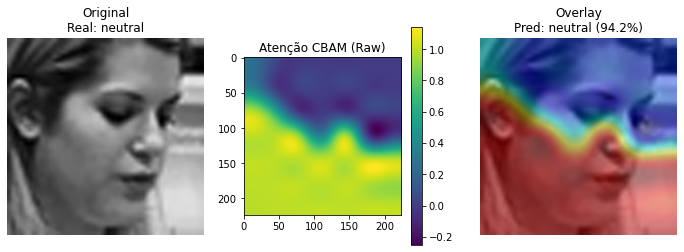

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import random

def preprocess_input_vggface_manual(x):
    x_temp = x.copy().astype('float32')
    if np.max(x_temp) <= 1.5:
        x_temp *= 255.0
        
    x_temp = x_temp[..., ::-1]
    x_temp[..., 0] -= 91.4953
    x_temp[..., 1] -= 103.8827
    x_temp[..., 2] -= 131.0912
    return x_temp

def visualize_cbam_attention(model, x_test, y_test, emotion_dict):
    try:
        idx = random.randint(0, len(x_test) - 1)
        img_raw = x_test[idx]
        label_true = np.argmax(y_test[idx])
        
        img_resized = cv2.resize(img_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
        
        if img_resized.ndim == 2:
            img_rgb = np.stack((img_resized,)*3, axis=-1)
        else:
            img_rgb = img_resized

        img_input = preprocess_input_vggface_manual(img_rgb)
        img_batch = np.expand_dims(img_input, axis=0)
    except Exception as e:
        print(f"Erro na preparação da imagem: {e}")
        return

    attention_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D) and layer.filters == 1 and layer.kernel_size == (7,7):
            attention_layer = layer
            break
            
    if not attention_layer:
        print("Erro: Camada de atenção espacial não encontrada.")
        return

    attention_model = Model(inputs=model.input, outputs=attention_layer.output)

    try:
        heatmap_raw = attention_model.predict(img_batch, verbose=0)
        heatmap = np.squeeze(heatmap_raw)
        
        print(f"DEBUG: Shape original do heatmap: {heatmap.shape}")


        if heatmap.ndim < 2:
            print("AVISO CRÍTICO: Modelo retornou um escalar (sem informação espacial).")
            print("Criando mapa artificial 7x7 para evitar travamento.")
            
            val = float(heatmap) if heatmap.size == 1 else 0.0
            heatmap = np.full((7, 7), val, dtype=np.float32)
        
        heatmap = heatmap.astype(np.float32)

    except Exception as e:
        print(f"Erro na extração do mapa: {e}")
        return

    try:
        img_disp = img_rgb.astype('uint8')

        heatmap_resized = cv2.resize(heatmap, (224, 224), interpolation=cv2.INTER_LANCZOS4)
        
        h_min, h_max = np.min(heatmap_resized), np.max(heatmap_resized)
        if h_max - h_min < 1e-5:
            heatmap_norm = heatmap_resized
        else:
            heatmap_norm = (heatmap_resized - h_min) / (h_max - h_min)
            
        heatmap_uint8 = np.uint8(255 * heatmap_norm)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        overlay = cv2.addWeighted(img_disp, 0.6, heatmap_color, 0.4, 0)
        
        logits = model.predict(img_batch, verbose=0)
        label_pred = np.argmax(logits)
        conf = np.max(tf.nn.softmax(logits))

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img_disp)
        plt.title(f"Original\nReal: {emotion_dict[label_true]}")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='viridis')
        plt.title("Atenção CBAM (Raw)")
        plt.colorbar()
        
        plt.subplot(1, 3, 3)
        plt.imshow(overlay)
        plt.title(f"Overlay\nPred: {emotion_dict[label_pred]} ({conf:.1%})")
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Erro na plotagem final: {e}")

print("Função blindada carregada.")
visualize_cbam_attention(model, x_test, y_test, emotion_dict)

### finetune all layer, lr=1e-4

In [32]:
# model = keras.models.load_model('model_v2_fase1_head_only.h5')

In [33]:
# for layer in model.layers[0].layers:
#     if 'bn' not in layer.name:
#         layer.trainable = True

In [34]:
# checkpoint_fase2 = ModelCheckpoint(
#     'model_v2_fase2_finetune_medium_lr.h5',
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

# model.compile(optimizer = keras.optimizers.Adam(1e-4), loss=loss_function, metrics=['accuracy'])
# hist2 = model.fit_generator(
#         generator=train_sequence,
#         validation_data=val_sequence,
#         epochs=10,
#         class_weight=class_weight_dict,
#         callbacks=[checkpoint_fase2] 
# )

In [35]:
# for key in ['accuracy','val_accuracy','loss','val_loss']:
#     hist.history[key] = hist.history[key] + hist2.history[key]

In [36]:
# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1)
# plt.plot(hist.history['accuracy'])
# plt.plot(hist.history['val_accuracy'])
# plt.subplot(1,2,2)
# plt.plot(hist.history['loss'])
# plt.plot(hist.history['val_loss'])

### finetune further all, lr=1e-5

In [37]:
# from keras.callbacks import ModelCheckpoint

# model = keras.models.load_model('model_v2_fase2_finetune_medium_lr.h5')

# # check_point = ModelCheckpoint('VGGfaceTransfer_dropout_smoothing_keras_model', 
# #                               monitor='val_acc', verbose=0, save_best_only=True,
# #                               save_weights_only=False, mode='auto', period=1)

# checkpoint_fase3 = ModelCheckpoint(
#     'model_v2_final.h5',
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )


# model.compile(optimizer = keras.optimizers.Adam(1e-5), loss=loss_function, metrics=['accuracy'])
# hist3 = model.fit_generator(
#         generator=train_sequence,
#         validation_data=val_sequence,
#         epochs=10,
#         class_weight=class_weight_dict,
#         callbacks=[checkpoint_fase3]
# )

In [38]:
ls

model_cbam_finetuned.h5          model_cbam_head_only_weights.h5
model_cbam_finetuned_weights.h5


In [39]:
# for key in ['accuracy','val_accuracy','loss','val_loss']:
#     hist.history[key] = hist.history[key] + hist3.history[key]

In [40]:
# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1)
# plt.plot(hist.history['accuracy'])
# plt.plot(hist.history['val_accuracy'])
# plt.subplot(1,2,2)
# plt.plot(hist.history['loss'])
# plt.plot(hist.history['val_loss'])

# model test

In [41]:
# model = keras.models.load_model('model_v2_final.h5')

In [42]:
# model.evaluate(test_sequence)

In [43]:
# model.save('VGGfaceTransfer_dropout_smoothing_keras_model_cbam')

In [44]:
# !tar -czvf VGGfaceTransfer_dropout_smoothing_keras_model.tar.gz VGGfaceTransfer_dropout_smoothing_keras_model

In [45]:
# from IPython.display import FileLink
# FileLink(r'VGGfaceTransfer_dropout_smoothing_keras_model_cbam.tar.gz')

### Confusion matrix

In [46]:
# y_pred = []
# y_true = []
# for x,y in test_sequence:
#     y_pred = y_pred + list(model.predict_classes(x))
#     y_true = y_true + list(np.argmax(y,axis=1))

In [47]:
# emotion_dict.values()

In [48]:
# emotion_dict

In [49]:
# confusion_matrix = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()
# confusion_matrix = np.around(confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis], decimals=2)

# confusion_matrix = pd.DataFrame(confusion_matrix,
#                                 index = emotion_dict.values(), 
#                                 columns = emotion_dict.values())

In [50]:
# import seaborn as sns
# figure = plt.figure(figsize=(8, 8))
# sns.heatmap(confusion_matrix, annot=True,cmap=plt.cm.Blues)
# plt.tight_layout()
# plt.ylabel('True label')
# plt.xlabel('Predicted label')
# plt.show()